In [2]:
import numpy as np
from numpy import pi
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
import itertools
colors = ['C0','C1','C2','C3','C4','C5','C6','C7','C8','C0','C1','C2','C3','C4','C5','C6','C7','C8']

from blochK.plotting import plot_FS, plot_bandstruc
from blochK.plotting.utils import sample_square, extent
from blochK.observable import exp_value_O,conductivity_orbital_resolved, local_dos_QPI, find_Gamma
import blochK

from alter_surf.hamiltonian_DLKK import create_H_DLKK_3D
from alter_surf.utils3D import projector2layer

from numpy import cos, sin 

In the entire script $k_z$ is the out of plane direction and $k_x,k_y$ are in plane. This makes more sense but is rotated with respect to the nature paper. This is implementing the stuff Fernando has on the overleaf

$(k_x,k_y,k_z) \rightarrow (k_x,k_z,-k_y)$

In [49]:
#implementing the overleaf of fernando


def H_2D_fct(kx,ky,t=1,t3=1,tz=1,Delta1=0,Delta2=0,mu=0,kz=0): 
    """
    translation invariant model of CuMnAs with kz as additional parameter
    ----------
    Parameters: (I just sticked with Fernando's notation)
    t: NN hopping in (x,y) plane?
    t3 NN hopping in (x,y) plane?
    tz: NN hopping in z direction?
    Delta1: splitting induced by staggered magnetism?
    Delta2: splitting induced by staggered magnetism?
    mu: Fermi energy
    kz: momentum in z direction
    """
    Hk = np.zeros((8,8,*kx.shape),dtype=complex) #Basis (A up, B up, A down, B down)

    fk = sin((kx+ky)/2) - sin((kx-ky)/2)
    gk = cos((kx+ky)/2) + cos((kx-ky)/2)
    hk = cos(kx)-cos(ky)

    #define hamiltonian for each spin sector
    def Hk_spin(spin:int):
        Hk = np.zeros((4,4,*kx.shape),dtype=complex)

        Hk[0,0] = Hk[1,1] = -mu
        Hk[2,2] = Hk[3,3] = -mu

        Hk[0,1] = t*gk
        Hk[2,3] = t*gk
        Hk[0,2] = t3*hk
        Hk[1,3] = t3*hk


        Hk[0,2] += tz*cos(kz/2) + spin* 1j*Delta1*sin(kz/2)
        Hk[1,3] += tz*cos(kz/2) - spin* 1j*Delta1*sin(kz/2)
        Hk[0,3] +=  1j*spin*Delta2*fk*cos(kz/2)
        Hk[1,2] += -1j*spin*Delta2*fk*cos(kz/2)

        return Hk
    
    #set hamiltonian structure
    Hk[:4,:4] = Hk_spin(spin=1)
    Hk[4:,4:] = Hk_spin(spin=-1)
    
    # make hermitian
    Hk = blochK.hamiltonian_fct.make_hermitian(Hk)

    return Hk


def H_3D_fct(kx,ky,len_z=2,t=1,t3=1,tz=1,Delta1=0,Delta2=0,mu=0,PBC=False): 
    """
    3D model of CuMnAs in slab geometry with len_z layers in z-direction
    ----------
    len_z: number of layers in z-direction
    Parameters: (I just sticked with Fernando's notation)
    t: NN hopping in (x,y) plane?
    tz: NN hopping in z direction?
    Delta1: splitting induced by staggered magnetism?
    Delta2: splitting induced by staggered magnetism?
    mu: Fermi energy
    PBC: periodic boundary conditions in z-direction
    """
    n_orbitals2D = 8 #number of orbitals in unit cell
    Hk = np.zeros((n_orbitals2D*len_z,n_orbitals2D*len_z,*kx.shape),dtype=complex)
    fk = sin((kx+ky)/2) - sin((kx-ky)/2)
    gk = cos((kx+ky)/2) + cos((kx-ky)/2)
    hk = cos(kx)-cos(ky)

    #define hamiltonian for each spin sector
    def H2D_spin(spin:int):
        Hk = np.zeros((4,4,*kx.shape),dtype=complex)

        Hk[0,0] = Hk[1,1] = -mu
        Hk[2,2] = Hk[3,3] = -mu

        Hk[0,1] = t*gk
        Hk[2,3] = t*gk
        Hk[0,2] = t3*hk
        Hk[1,3] = t3*hk
        return Hk

        Hk[0,2] += tz*cos(kz/2) + spin* 1j*Delta1*sin(kz/2)
        Hk[1,3] += tz*cos(kz/2) - spin* 1j*Delta1*sin(kz/2)
        Hk[0,3] +=  1j*spin*Delta2*fk*cos(kz/2)
        Hk[1,2] += -1j*spin*Delta2*fk*cos(kz/2)

    #hoppings in x,y plane
    Hk_2D = np.zeros((n_orbitals2D,n_orbitals2D,*kx.shape),dtype=complex)
    Hk_2D[:4,:4] = H2D_spin(spin=1)
    Hk_2D[4:,4:] = H2D_spin(spin=-1)
    #fill diagonal blocks
    for j in range(len_z):
         Hk[n_orbitals2D*j:n_orbitals2D*j+n_orbitals2D, n_orbitals2D*j:n_orbitals2D*j+n_orbitals2D] = Hk_2D

    #hoppings in z-direction, 3D
    def Hz_spin(spin:int):
        Hk = np.zeros((4,4,*kx.shape),dtype=complex)

        Hk[0,2] += tz/2 + spin* 1j*Delta1/2
        Hk[1,3] += tz/2 - spin* 1j*Delta1/2
        Hk[0,3] +=  1j*spin*Delta2*fk/2
        Hk[1,2] += -1j*spin*Delta2*fk/2

        return Hk
    
    Hz = np.zeros((n_orbitals2D,n_orbitals2D,*kx.shape),dtype=complex)
    Hz[:4,:4] = Hz_spin(spin=1)
    Hz[4:,4:] = Hz_spin(spin=-1)
    #add NN hoppings in z-direction blocks
    for j in range(len_z-1):
        Hk[n_orbitals2D*j:n_orbitals2D*(j+1), n_orbitals2D*(j+1):n_orbitals2D*(j+2)] = Hz #upper block

    if PBC: # Periodic boundary conditions
        Hk[0:n_orbitals2D,n_orbitals2D*(len_z-1):n_orbitals2D*len_z] = Hz

    # add lower block by hermiticity
    Hk = blochK.hamiltonian_fct.make_hermitian(Hk)

    return Hk



Hparam0 = dict(t=1, tz=1,t3=1, Delta1=0, Delta2=1, mu=0)
H2D = blochK.Hamiltonian2D(H_2D_fct, param=Hparam0)

H2D.add_operator('spin',np.array([1,1,1,1,-1,-1,-1,-1]))


Hparam0 = dict(len_z=10, t=1, tz=1,t3=1, Delta1=0, Delta2=1, mu=0, PBC=False)
H = blochK.Hamiltonian2D(H_3D_fct, param=Hparam0)

H.add_suboperator('spin',np.array([1,1,1,1,-1,-1,-1,-1]))


In [38]:
#the overleaf of fernando send, ignore this for now.


def H_3D_fct(kx,ky,len_z=2,t1=1,t2=1,t3=1,Delta_z=0,mu=0,PBC=False): 
    """
    len_z: number of layers in z-direction
    t1
    t2
    t3
    Delta_z
    mu
    PBC: periodic boundary conditions in z-direction
    """
    n_orbitals2D = 4 #number of orbitals in 2D unit cell
    Hk = np.zeros((n_orbitals2D*len_z,n_orbitals2D*len_z,*kx.shape),dtype=complex)
    
    for j in range(len_z):
         Hk[n_orbitals2D*j:n_orbitals2D*j+n_orbitals2D, n_orbitals2D*j:n_orbitals2D*j+n_orbitals2D] = H_2D_fct(kx,ky,t1=t1,t3=t3,Delta_z=Delta_z,mu=mu)

    #extend to 3D
    #z-hoppings
    Hz = np.zeros((n_orbitals2D,n_orbitals2D,*kx.shape),dtype=complex)
    # couples z=0 block to z=1 block
    Hk[1,2] = Hk[0,3] = -t3
    Hk[2,1] = Hk[3,0] = -t3
    
    #add to final Hamiltonian
    for j in range(len_z-1):
        Hk[n_orbitals2D*j:n_orbitals2D*j+n_orbitals2D, n_orbitals2D*(j+1):n_orbitals2D*(j+1)+n_orbitals2D] = Hz #upper block
        Hk[n_orbitals2D*(j+1):n_orbitals2D*(j+1)+n_orbitals2D, n_orbitals2D*j:n_orbitals2D*j+n_orbitals2D] = Hz #lower block

    if PBC: # Periodic boundary conditions
        Hk[n_orbitals2D*(len_z-1):n_orbitals2D*len_z,0:n_orbitals2D] = Hz
        Hk[0:n_orbitals2D,n_orbitals2D*(len_z-1):n_orbitals2D*len_z] = Hz

    return Hk


H = blochK.Hamiltonian2D(H_2D_fct, param=dict(t=1, tz=1, Delta1=1, Delta2=1, mu=0))

H.add_suboperator('spin',np.kron(np.array([1,-1]),np.ones(4)))






filling is:  0.49997


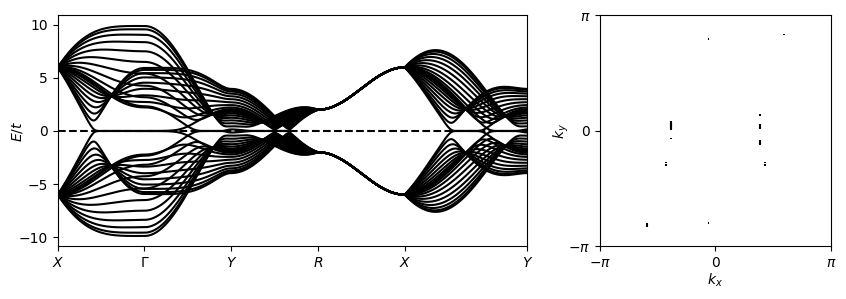

In [ ]:

H2D.update_params(dict(t1=0.1, t2=0.5, t3=0.2, Delta_z=1,mu=-0.05,kz=0.1))
#H.update_params(dict(t1=0.1, t2=0.5, t3=0.2, Delta_z=0.4,mu=-0.0,PBC=False))

labels = ['Y','\Gamma',"X","R","Y",'X']
labels = ['X','\Gamma',"Y","R","X",'Y']
coloring_operator = None
cmap = 'bwr'


fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
plot_bandstruc(ax,H,labels_points_path=labels,cmap=cmap)
plot_FS(ax1,H,cmap=cmap,Lk=50,print_filling=True)


## Looking at different k_z momenta

I pushed the Fermi energy a little bit down to see the Fermi surface of the 2 bands which merge to create the nodal line.

Nodal line seems to persist away from $k_z=0$?

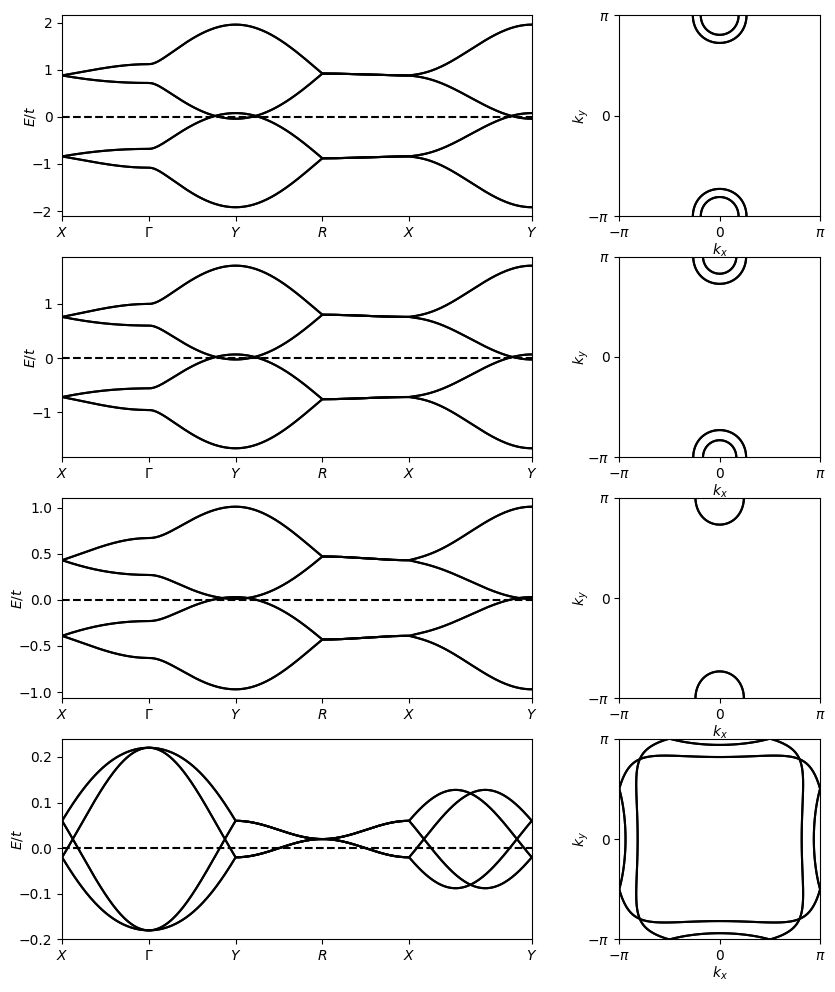

In [46]:
Hparams = dict(t=0.1, tz=0.9,t3=0.02, Delta1=0., Delta2=[0.5], mu=-0.02,kz=np.linspace(0,np.pi,4)) #np.linspace(0,np.pi,4)

Hparam_list = blochK.utils.parameters.dict2listofdict(Hparams)

labels = ['X','\Gamma',"Y","R","X",'Y']
coloring_operator = None
cmap = 'bwr'


fig, axs = plt.subplots(len(Hparam_list),2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3*len(Hparam_list)))

for Hparam,ax in zip(Hparam_list, axs):
    H2D.update_params(Hparam)
    plot_bandstruc(ax[0],H2D,labels_points_path=labels,cmap=cmap)
    plot_FS(ax[1],H2D,cmap=cmap,Lk=200,print_filling=False)

## Looking at the Projection along z-direction

This looks roughly the same. There is a flat band connecting the Weyl cones for slab geometry and PBC. I guess this is the nodal line? No this doesn't make sense. It seems like one of the 2 bands we have in becomes this flat state?

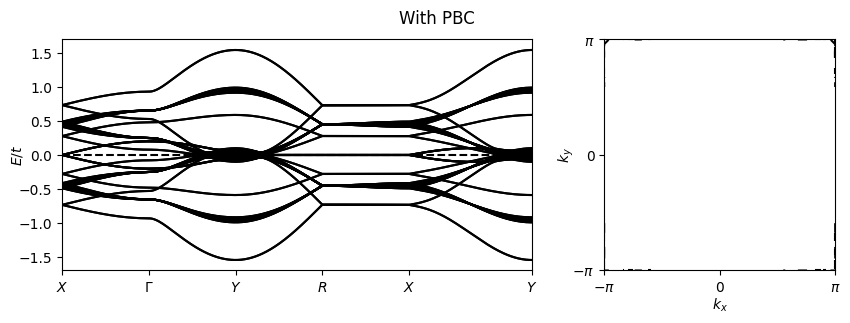

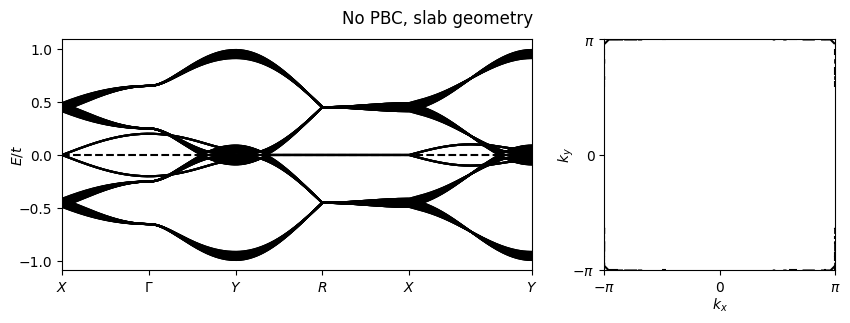

In [54]:
H.update_params(dict(t=0.1, tz=0.9,t3=0.02, Delta1=0., Delta2=0.5,mu=0,))

labels = ['X','\Gamma',"Y","R","X",'Y']
coloring_operator = None
cmap = 'bwr'

#with PBC
H.update_params(dict(PBC=True))

fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
fig.suptitle('With PBC')
plot_bandstruc(ax,H,labels_points_path=labels,cmap=cmap)
plot_FS(ax1,H,cmap=cmap,Lk=50,)

#without PBC
H.update_params(dict(PBC=False))

fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
fig.suptitle('No PBC, slab geometry')
plot_bandstruc(ax,H,labels_points_path=labels,cmap=cmap)
plot_FS(ax1,H,cmap=cmap,Lk=50,)


## Computing surface properties

In [61]:
Lq = 50 #number of k-points in each direction

# Define the k-point grid
ks = sample_square(Lq)
#Diagonalize Hamiltonian
H.update_params(dict(PBC=False,mu=0.05))
es,psis = H.diagonalize(*ks)

def plot_spectral_density(ax,spectral_density,cmap='bwr',title_plot='',show_xlabel=True,show_ylabel=True,vmax='',vmin=''):
    """Plots colored spin spectral density on ax,

    cmap: a matplotlib colormap
    title_plot: title of the plot if given
    vmax: maximum value for color scaling
    """
    if title_plot!='':
         ax.set_title(title_plot,fontsize=6)
    ax.set_aspect('equal')
    if show_xlabel:
        ax.set_xlabel('$k_x$',labelpad=1)
        ax.set_xticks([-pi,0,pi])
        ax.set_xticklabels(['$-\pi$',0,'$\pi$'])
    else:
        ax.set_xticklabels([])
    if show_ylabel:
        ax.set_ylabel('$k_y$',labelpad=-2.5)
        ax.set_yticks([-pi,0,pi])
        ax.set_yticklabels(['$-\pi$',0,'$\pi$'])
    else:
        ax.set_yticklabels([])
    ax.set_xlim(-pi,pi)
    ax.set_ylim(-pi,pi)
    #--------------
    if vmax == '':
        vmax = np.abs(spectral_density).max()
    if vmin == '':
        vmin = -vmax
    im = ax.imshow(spectral_density.T,extent=(-pi,pi,-pi,pi),origin='lower',cmap=cmap,norm=matplotlib.colors.LogNorm(vmin=1e-5,vmax=vmax))
    return im




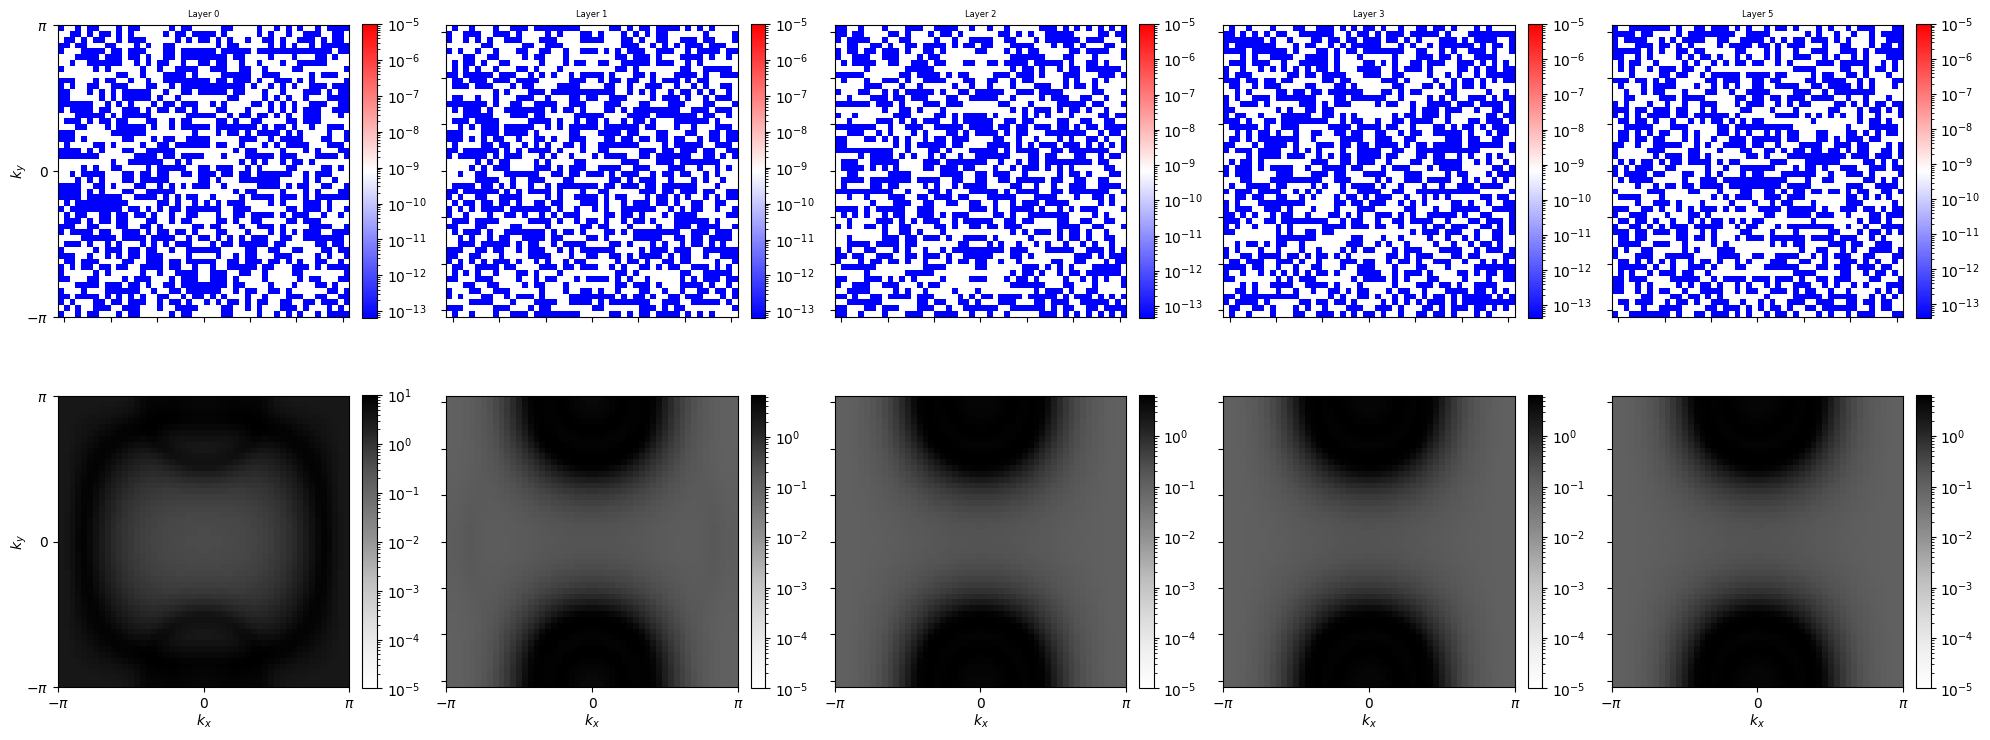

In [63]:

Gamma = find_Gamma(es)
len_z = Hparam0['len_z']
#layers = [0,len_z//6,len_z//3,len_z//2]
layers = np.linspace(0,len_z//2,5,dtype=int)

#Plot
fig,axs = plt.subplots(2,len(layers),figsize=(4*len(layers),8))

for ax_column,layer in zip(axs.T,layers):
    proj_2layers = projector2layer(layer,len_z=len_z)
    coloring_operator = np.kron(proj_2layers,H.suboperator.spin) #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
    spectral_density_spin = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z

    #compute spectral density
    Os = exp_value_O(np.kron(proj_2layers,np.ones(H.n_orbitals//len_z)),psis) #.shape=(n,y,x)
    spectral_density0 = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z

    
    vmax_spin = np.abs(spectral_density_spin).max()
    vmax0 = np.abs(spectral_density0).max()

    imT = plot_spectral_density(ax_column[0],spectral_density_spin,title_plot='Layer '+str(layer),show_ylabel=(layer==0),show_xlabel=False,vmax=vmax_spin)
    imB = plot_spectral_density(ax_column[1],spectral_density0,show_ylabel=(layer==0),show_xlabel=True,vmax=vmax0,vmin=0,cmap='Greys')
    
    #colorbars for each plot
    plt.colorbar(imT,ax=ax_column[0],fraction=0.046,pad=0.04)
    plt.colorbar(imB,ax=ax_column[1],fraction=0.046,pad=0.04)    


# plt.colorbar(imT,ax=axs[0,-1],fraction=0.046,pad=0.04)
# plt.colorbar(imB,ax=axs[1,-1],fraction=0.046,pad=0.04)

plt.tight_layout()
